In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Crop Recommendation Data Analysis :**


---
**- Objective :**


To analyze how soil nutrients and environmental factors affect crop selection.

#📊 Dataset Features :



- N, P, K ➡ Soil nutrients

- Temperature, Humidity ➡ Climate

- pH ➡ Soil Condition

- Rainfall ➡ Water availability

- Label ➡ Crop Type

In [21]:
df=pd.read_csv("/content/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [22]:
df.info()
df.shape
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [23]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

## ***📌 Insight :***
 -  Dataset has no missing values
 -  All features are numerical except label

In [24]:
df["label"].unique()
df["label"].value_counts()

,count
label,
rice,100
maize,100
chickpea,100
kidneybeans,100
pigeonpeas,100
mothbeans,100
mungbean,100
blackgram,100
lentil,100


## ***📌 Insight :***
- Dataset contains multiple crop types with balanced distribution

In [25]:
df["total_nutrients"]=df["N"]+df["P"]+df["K"]
df["avg_nutrients"]=(df["N"]+df["P"]+df["K"])/3
df["rainfall_Level"]=df["rainfall"].apply(lambda x:"Low" if x<100 else "Medium" if x<200 else "High")
df["ph_category"]=df["ph"].apply(lambda x:"Acidic" if x<=6.5 else "Neutral" if 6.5<=x<=7.5 else "Alkaline")
df["temp_category"]=df["temperature"].apply(lambda x:"Cool" if x<20 else "Moderate" if x<=30 else "Hot")
df

,N,P,K,temperature,humidity,ph,rainfall,label,total_nutrients,avg_nutrients,rainfall_Level,ph_category,temp_category
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,175,58.333333,High,Neutral,Moderate
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,184,61.333333,High,Neutral,Moderate
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,159,53.000000,High,Alkaline,Moderate
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,149,49.666667,High,Neutral,Moderate
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,162,54.000000,High,Alkaline,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee,173,57.666667,Medium,Neutral,Moderate
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee,141,47.000000,Medium,Acidic,Moderate
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee,181,60.333333,Medium,Acidic,Moderate
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee,183,61.000000,Medium,Neutral,Moderate


In [26]:
crop_conditions=df.groupby("label").agg({
    "N": ["min","max"],
    "P": ["min","max"],
    "K": ["min", "max"],
    "temperature": ["min","max"],
    "humidity": ["min","max"],
    "ph": ["min","max"],
    "rainfall": ["min","max"]
})
crop_conditions.columns=["_".join(col) for col in crop_conditions.columns]
crop_conditions = crop_conditions.reset_index()
crop_conditions

,label,N_min,N_max,P_min,P_max,K_min,K_max,temperature_min,temperature_max,humidity_min,humidity_max,ph_min,ph_max,rainfall_min,rainfall_max
0,apple,0,40,120,145,195,205,21.036527,23.996862,90.025751,94.920481,5.514253,6.499227,100.117344,124.983162
1,banana,80,120,70,95,45,55,25.010185,29.908885,75.031933,84.978492,5.505394,6.490074,90.109781,119.847970
2,blackgram,20,60,55,80,15,25,25.097374,34.946616,60.065349,69.961000,6.500145,7.775306,60.417903,74.915595
3,chickpea,20,60,55,80,75,85,17.024985,20.995022,14.258040,19.969789,5.988993,8.868741,65.113656,94.781896
4,coconut,0,40,5,30,25,35,25.008724,29.869083,90.017345,99.981876,5.501580,6.470466,131.090008,225.632366
5,coffee,80,120,15,40,25,35,23.059519,27.923744,50.045570,69.948073,6.020947,7.493192,115.156401,199.473564
6,cotton,100,140,35,60,15,25,22.000851,25.992374,75.005393,84.876690,5.801048,7.994680,60.653817,99.931008
7,grapes,0,40,120,145,195,205,8.825675,41.948657,80.016394,83.983517,5.510925,6.499605,65.010953,74.915062
8,jute,60,100,35,60,35,45,23.094338,26.985822,70.882596,89.891065,6.002525,7.488014,150.235524,199.836291
9,kidneybeans,0,40,55,80,15,25,15.330426,24.923601,18.092240,24.969699,5.502999,5.998125,60.275525,149.744103


In [27]:
df.groupby("label").mean(numeric_only=True)

,N,P,K,temperature,humidity,ph,rainfall,total_nutrients,avg_nutrients
label,,,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779,354.91,118.303333
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980,232.29,77.430000
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151,126.73,42.243333
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977,187.80,62.600000
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646,69.50,23.166667
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295,159.88,53.293333
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043,183.57,61.190000
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829,355.82,118.606667
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798,165.25,55.083333


## ***📌 Insight :***
- Each crop has different environmental and nutrient requirements

In [28]:
df.groupby(["ph_category", "label"]).size()

ph_category  label      
Acidic       apple          100
             banana         100
             chickpea        21
             coconut        100
             coffee          27
             cotton          33
             grapes         100
             jute            35
             kidneybeans    100
             lentil          26
             maize           68
             mango           85
             mothbeans       45
             mungbean        28
             muskmelon       71
             orange          26
             pigeonpeas      79
             pomegranate     52
             rice            55
             watermelon      52
Alkaline     blackgram       20
             chickpea        44
             cotton          21
             lentil          19
             mothbeans       45
             orange          26
             rice            10
Neutral      blackgram       80
             chickpea        35
             coffee          73
             cotton          46
             jute            65
             lentil          55
             maize           32
             mango           15
             mothbeans       10
             mungbean        72
             muskmelon       29
             orange          48
             papaya         100
             pigeonpeas      21
             pomegranate     48
             rice            35
             watermelon      48
dtype: int64

In [29]:
df.groupby(["temp_category", "label"]).size()

temp_category  label      
Cool           chickpea        79
               grapes          41
               kidneybeans     51
               lentil          11
               maize           27
               orange          36
               pigeonpeas      16
               pomegranate     30
Hot            blackgram       48
               grapes          27
               mango           65
               mothbeans       27
               orange          23
               papaya          68
               pigeonpeas      40
Moderate       apple          100
               banana         100
               blackgram       52
               chickpea        21
               coconut        100
               coffee         100
               cotton         100
               grapes          32
               jute           100
               kidneybeans     49
               lentil          89
               maize           73
               mango           35
               mothbeans       73
               mungbean       100
               muskmelon      100
               orange          41
               papaya          32
               pigeonpeas      44
               pomegranate     70
               rice           100
               watermelon     100
dtype: int64

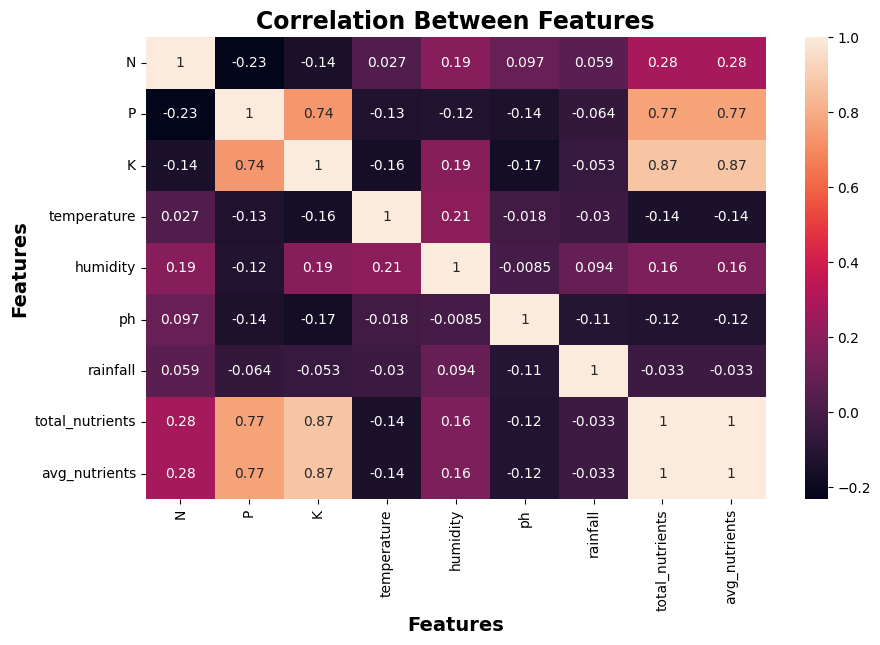

In [30]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Between Features", fontweight="bold", fontsize=17)
plt.xlabel("Features", fontweight="bold", fontsize=14)
plt.ylabel("Features", fontweight="bold", fontsize=14)
plt.show()

# 📌  Heatmap Insight :

- Temperature and humidity show moderate correlation  
- Nutrients (N, P, K) are not strongly correlated  
- Rainfall is relatively independent  

This indicates that each feature contributes uniquely to crop selection.

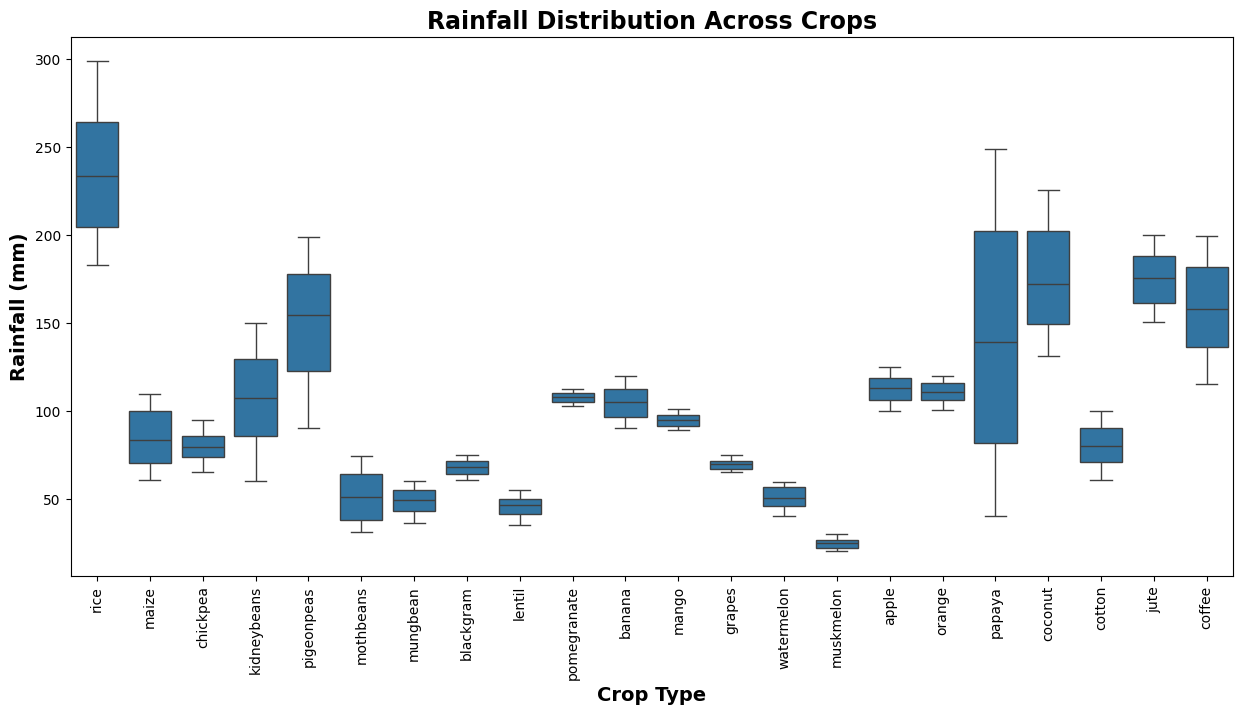

In [31]:
plt.figure(figsize=(15,7))
sns.boxplot(x="label", y="rainfall", data=df)
plt.title("Rainfall Distribution Across Crops", fontweight="bold", fontsize=17)
plt.xlabel("Crop Type", fontweight="bold", fontsize=14)
plt.ylabel("Rainfall (mm)", fontweight="bold", fontsize=14)
plt.xticks(rotation=90)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

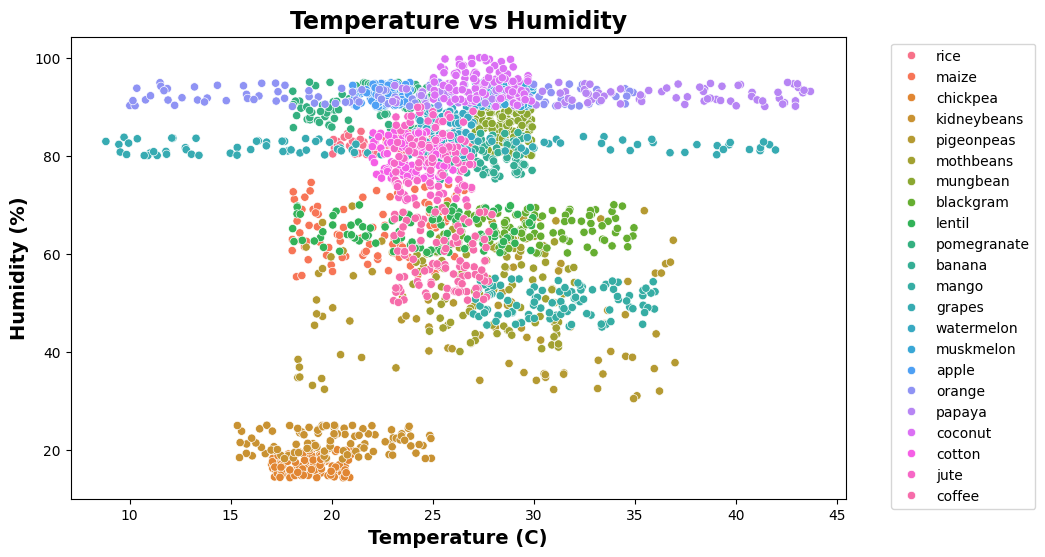

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="temperature", y="humidity", hue="label", data=df)
plt.title("Temperature vs Humidity", fontweight="bold", fontsize=17)
plt.xlabel("Temperature (C)", fontweight="bold", fontsize=14)
plt.ylabel("Humidity (%)", fontweight="bold", fontsize=14)
plt.legend(bbox_to_anchor=(1.05,1))
plt.show

In [33]:
# Top crop by rainfall
df.groupby("label")["rainfall"].mean().sort_values(ascending=False)

,rainfall
label,
rice,236.181114
coconut,175.686646
jute,174.792798
coffee,158.066295
pigeonpeas,149.457564
papaya,142.627839
apple,112.654779
orange,110.474969
pomegranate,107.528442


In [34]:
# Top crop by nutrients
df.groupby("label")["total_nutrients"].mean().sort_values(ascending=False)

,total_nutrients
label,
grapes,355.82
apple,354.91
banana,232.29
chickpea,187.80
cotton,183.57
muskmelon,168.12
rice,167.34
watermelon,166.64
jute,165.25


In [35]:
# Ideal conditions table
df.groupby("label").agg({"temperature" : "mean", "humidity" : "mean", "ph" : "mean"})

,temperature,humidity,ph
label,,,
apple,22.630942,92.333383,5.929663
banana,27.376798,80.358123,5.983893
blackgram,29.973340,65.118426,7.133952
chickpea,18.872847,16.860439,7.336957
coconut,27.409892,94.844272,5.976562
coffee,25.540477,58.869846,6.790308
cotton,23.988958,79.843474,6.912675
grapes,23.849575,81.875228,6.025937
jute,24.958376,79.639864,6.732778


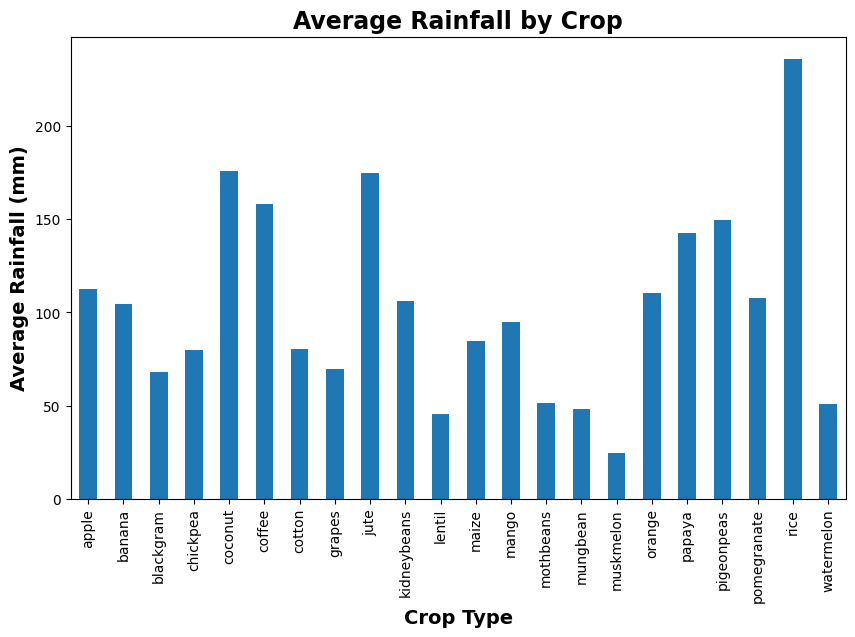

In [36]:
plt.figure(figsize=(10,6))
df.groupby("label")["rainfall"].mean().plot(kind="bar")
plt.title("Average Rainfall by Crop", fontweight="bold", fontsize=17)
plt.xlabel("Crop Type", fontweight="bold", fontsize=14)
plt.ylabel("Average Rainfall (mm)", fontweight="bold", fontsize=14)
plt.show()

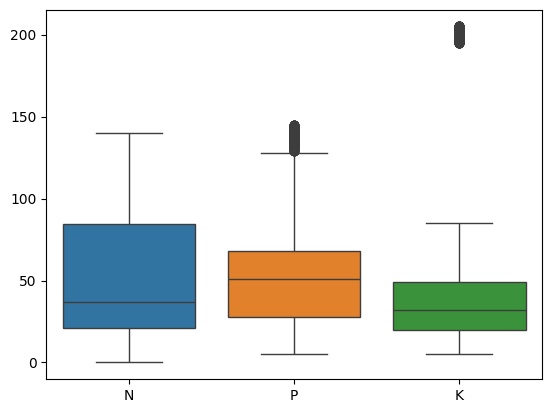

In [37]:
sns.boxplot(data=df[["N", "P", "K"]])
plt.show()

# **📌  Crop Suitability Insights :**

- Rice requires rainfall above ~200 mm and humidity above ~70%

- Most crops grow best in pH range of 6-7 (neutral)

- Balanced nutrients improve crop growth



In [38]:
df["score"]=df["total_nutrients"]+df["rainfall"]
df.groupby("label")["score"].mean().sort_values(ascending=False)

,score
label,
apple,467.564779
grapes,425.431829
rice,403.521114
jute,340.042798
banana,336.916980
coffee,317.946295
papaya,301.597839
chickpea,267.858977
cotton,263.968043


# **✅ Conclusion**

**This analysis helps in selectiong the most suitable crop based on soil nutrients and environmental conditions, improving agricultural productivity and decision-making.**